## IrisFlowerClassification

In [10]:
import pandas as pd
from sklearn.datasets import load_iris

In [11]:
# Load the Iris dataset
iris = load_iris()
# Convert to a pandas DataFrame for easier EDA
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

print("Iris Dataset loaded successfully!")

Iris Dataset loaded successfully!


In [12]:
# 1. Dataset Shape
print("\nShape of the dataset:")
print(iris_df.shape)


Shape of the dataset:
(150, 5)


In [13]:
# 2. Data Types
print("\nData types of each column:")
display(iris_df.dtypes)


Data types of each column:


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

In [14]:
# 3. Null Value Check
print("\nNull values in each column:")
display(iris_df.isnull().sum())


Null values in each column:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [15]:
# 4. Descriptive Statistics
print("\nDescriptive statistics of the dataset:")
display(iris_df.describe())


Descriptive statistics of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

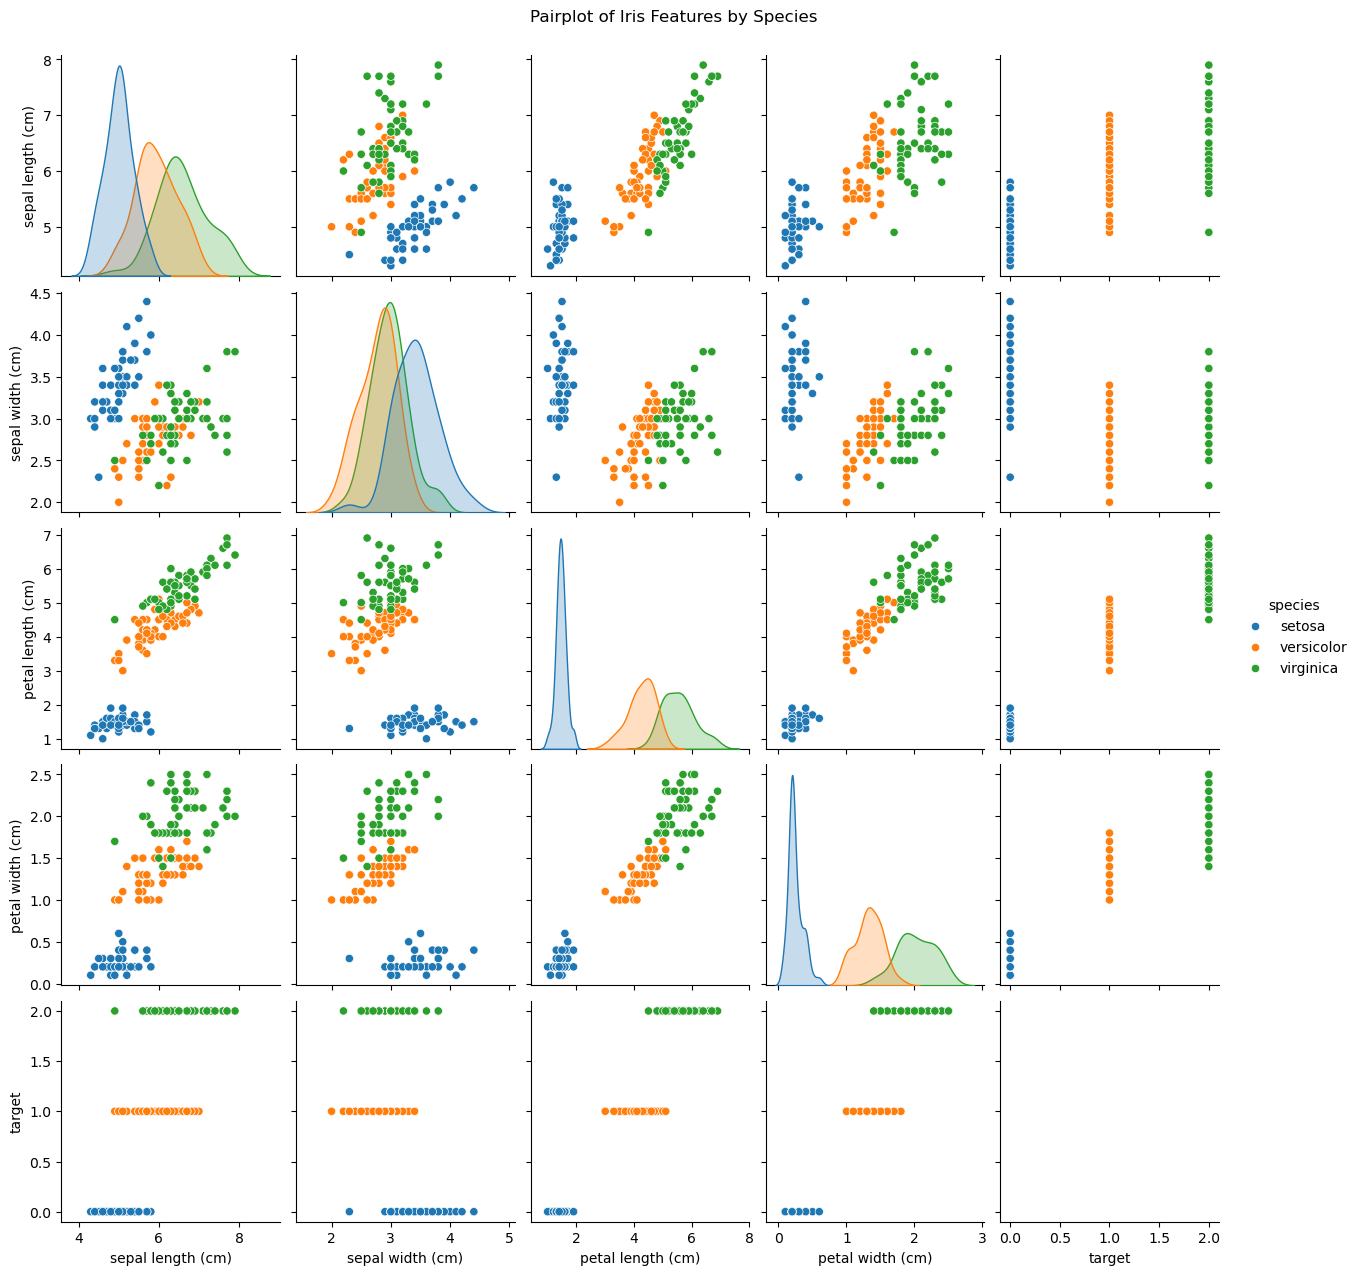

In [18]:
# Map target integers to species names for better readability in plots
iris_df['species'] = iris_df['target'].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

# Pairplot/Scatter Matrix
sns.pairplot(iris_df, hue='species', diag_kind='kde')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02) # Add a title
plt.show()

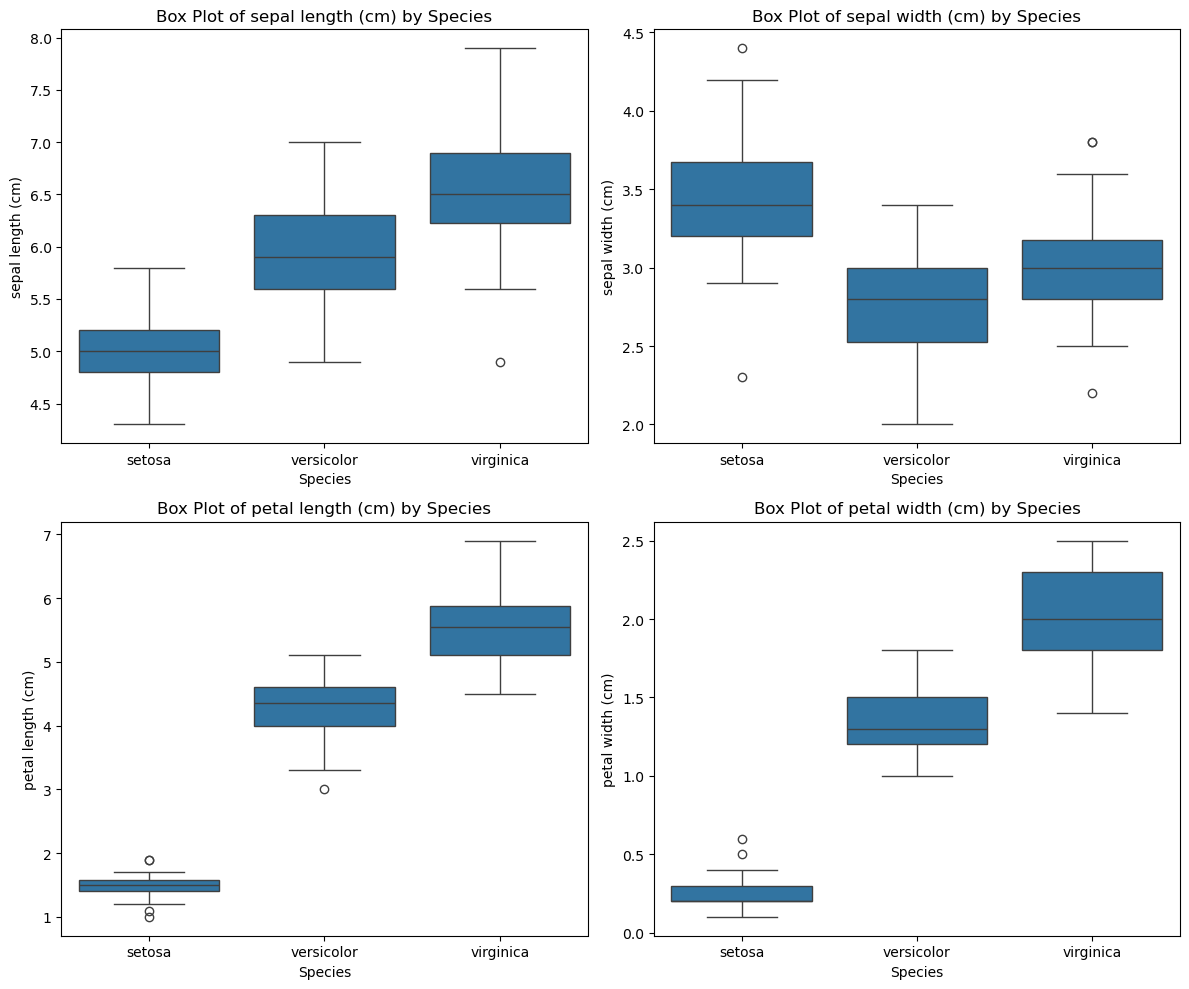

In [19]:
# Box plots for each feature

plt.figure(figsize=(12, 10))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=feature, x='species', data=iris_df)
    plt.title(f'Box Plot of {feature} by Species')
    plt.xlabel('Species')
    plt.ylabel(feature)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare the data for feature selection
X = iris_df.drop(['target', 'species'], axis=1) # Features
y = iris_df['target'] # Target variable

# Split data into training and testing sets (optional but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Feature Importances from RandomForestClassifier:")
display(feature_importances)

Feature Importances from RandomForestClassifier:


petal width (cm)     0.433982
petal length (cm)    0.417308
sepal length (cm)    0.104105
sepal width (cm)     0.044605
dtype: float64

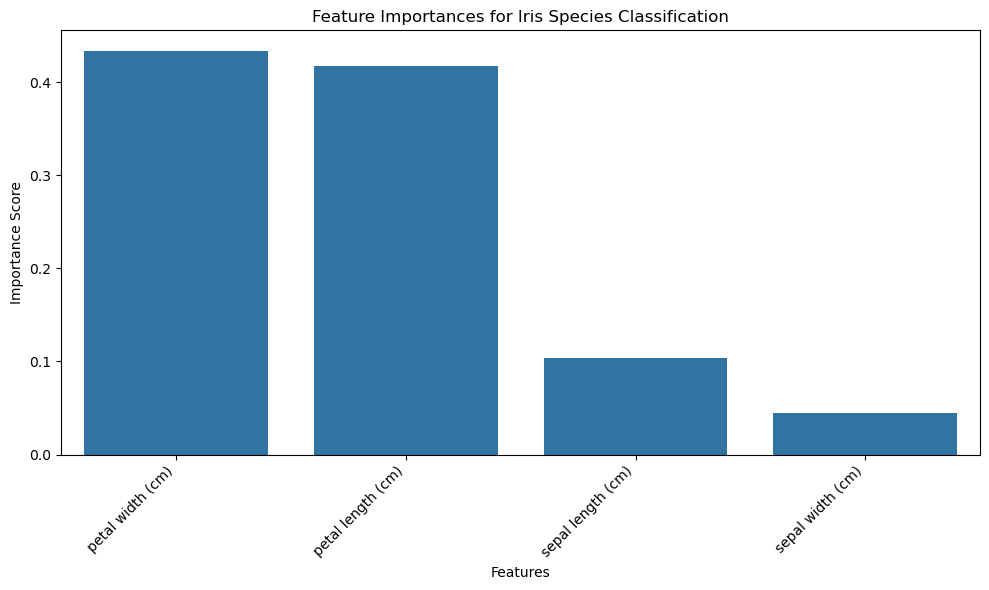

In [21]:
# Plotting feature importances
fig = plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.index, y=feature_importances.values)
plt.title('Feature Importances for Iris Species Classification')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Split the data into training and testing sets
# Using the same X and y defined for feature selection
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=200, random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

Logistic Regression Model Performance:
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



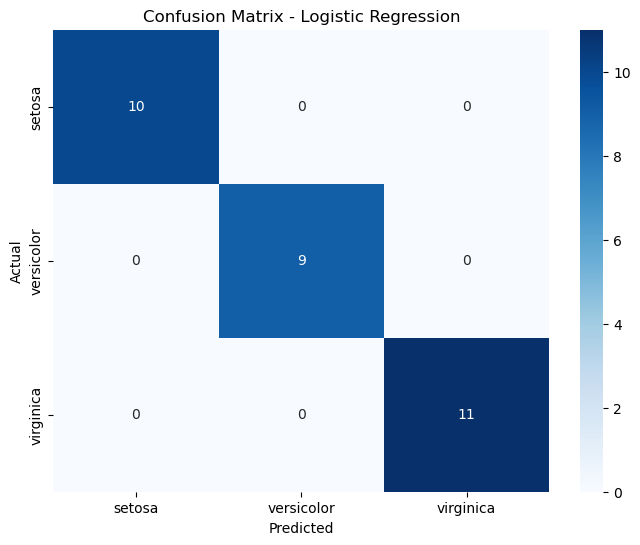

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [24]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the K-Nearest Neighbors model
# Using n_neighbors=5 as a common starting point
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
print("K-Nearest Neighbors Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

K-Nearest Neighbors Model Performance:
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



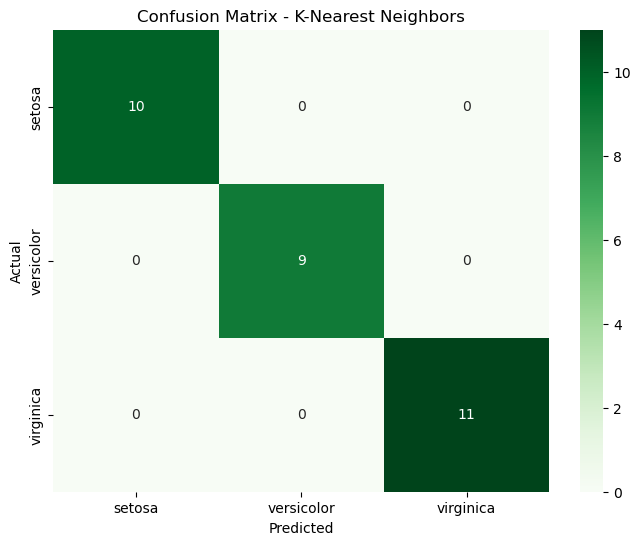

In [26]:
# Confusion Matrix for K-Nearest Neighbors
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Both Logistic Regression and K-Nearest Neighbors models are the best-performing models, as they both achieved 100% accuracy on the test set. Their confusion matrices and classification reports showed no errors, indicating perfect prediction of all Iris species.